In [21]:
import numpy as np
import pandas as pd
import os

In [22]:
path = '../data/processed/data.csv'
if os.path.exists('../data/processed/data.csv'):
    print('Le fichier existe')

Le fichier existe


In [23]:
data = pd.read_csv(path)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   valence_intensity    30000 non-null  float64
 1   fear_intensity       30000 non-null  float64
 2   anger_intensity      30000 non-null  float64
 3   happiness_intensity  30000 non-null  float64
 4   sadness_intensity    30000 non-null  float64
 5   sentiment            30000 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 1.4 MB


In [25]:
X = data.drop(columns=['sentiment'])

In [26]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   valence_intensity    30000 non-null  float64
 1   fear_intensity       30000 non-null  float64
 2   anger_intensity      30000 non-null  float64
 3   happiness_intensity  30000 non-null  float64
 4   sadness_intensity    30000 non-null  float64
dtypes: float64(5)
memory usage: 1.1 MB


In [27]:

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Clustering agglomératif
linkage='ward' : Utilise la méthode de Ward qui minimise la variance intra-cluster.
n_clusters=None et distance_threshold=0 : Permettent de ne pas spécifier de nombre de clusters initialement, pour générer un dendrogramme complet.

In [28]:
# Étape 2 : Clustering agglomératif
agg_clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=0, linkage='ward')
agg_clustering.fit(X)

AgglomerativeClustering(distance_threshold=0, n_clusters=None)

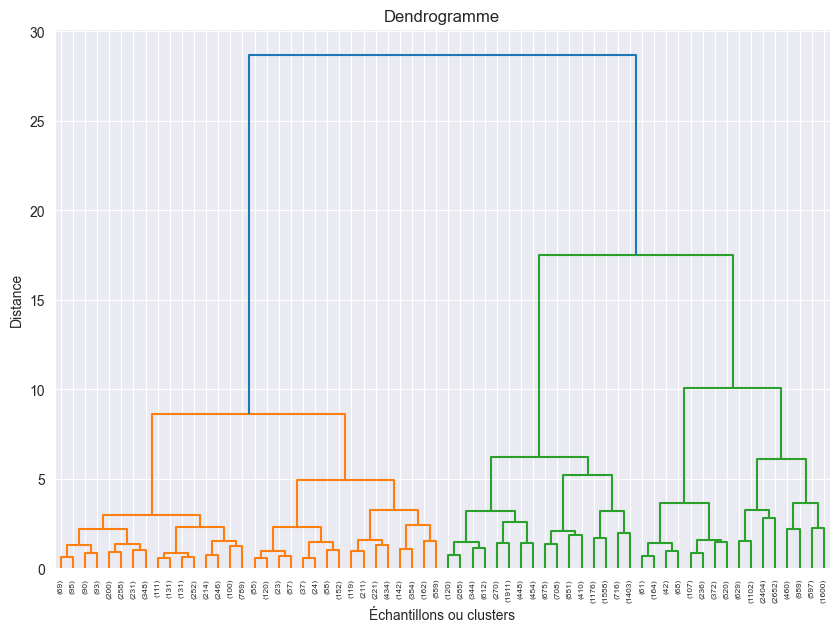

In [29]:
# Étape 3 : Visualisation avec un dendrogramme
linked = linkage(X, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked, truncate_mode='level', p=5)  # Ajuster p pour afficher plus ou moins de niveaux
plt.title('Dendrogramme')
plt.xlabel('Échantillons ou clusters')
plt.ylabel('Distance')
plt.show()

In [ ]:
# Étape 4 : Extraction des clusters
from scipy.cluster.hierarchy import fcluster
max_d = 5
clusters = fcluster(linked, max_d, criterion='distance')
clusters